2 Getting Started with Image Processing with Python.
Introduction to Python Imaging Library(PIL)
2.1 Exercise - 1:
Complete all the Task.
1. Read and display the image.
• Read the image using the Pillow library and display it.
• You can also use matplotlib to display the image.
2. Display only the top left corner of 100x100 pixels.
• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing.
3. Show the three color channels (R, G, B).
• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}
4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:
• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.

In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

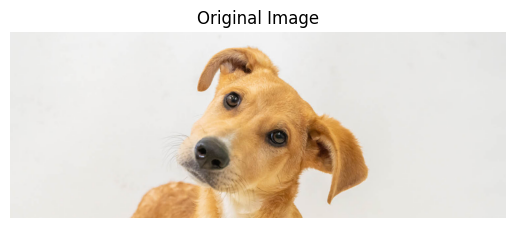

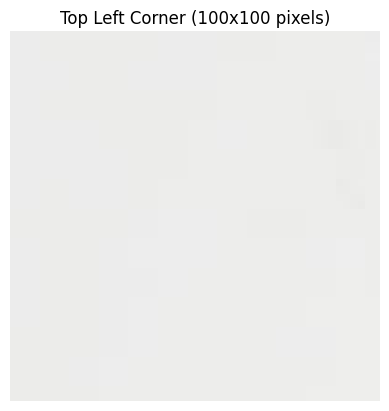

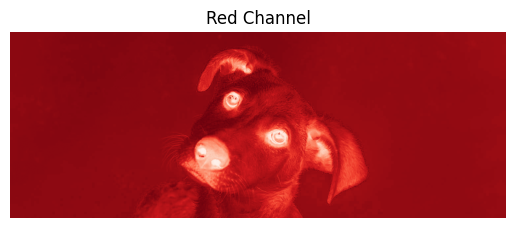

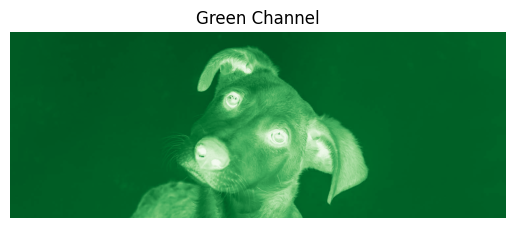

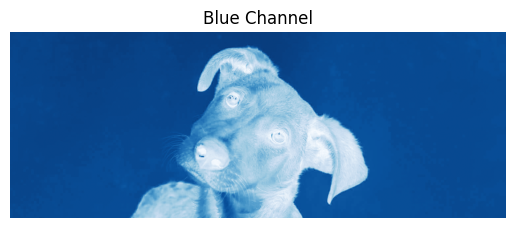

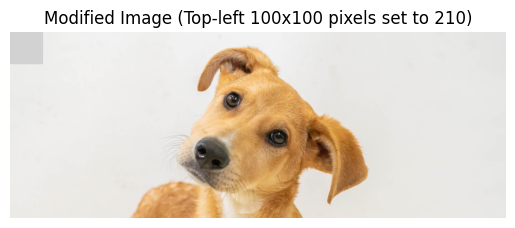

In [4]:
image_path = '/content/dog.jpg'  # Replace with your image path
image = Image.open(image_path)

# Display the image using matplotlib
plt.imshow(image)
plt.axis('off')  # Hide axes
plt.title('Original Image')
plt.show()

# Convert the image to a NumPy array
image_array = np.array(image)

# Extract the top-left corner of the image (100x100 pixels)
top_left_corner = image_array[:100, :100]
# Display the top-left corner
plt.imshow(top_left_corner)
plt.axis('off')  # Hide axes
plt.title('Top Left Corner (100x100 pixels)')
plt.show()

# Separate the image into its three color channels (R, G, B)
red_channel = image_array[:, :, 0]   # Red channel
green_channel = image_array[:, :, 1] # Green channel
blue_channel = image_array[:, :, 2]  # Blue channel
# Display the Red channel
plt.imshow(red_channel, cmap='Reds')
plt.axis('off')  # Hide axes
plt.title('Red Channel')
plt.show()

# Display the Green channel
plt.imshow(green_channel, cmap='Greens')
plt.axis('off')  # Hide axes
plt.title('Green Channel')
plt.show()

# Display the Blue channel
plt.imshow(blue_channel, cmap='Blues')
plt.axis('off')  # Hide axes
plt.title('Blue Channel')
plt.show()

# Modify the pixel values of the top-left 100 × 100 region to have a value of 210
image_array[:100, :100] = 210  # Set the top-left 100x100 pixels to a light gray color (210)
# Convert the modified array back to an image
modified_image = Image.fromarray(image_array)
# Display the modified image
plt.imshow(modified_image)
plt.axis('off')  # Hide axes
plt.title('Modified Image (Top-left 100x100 pixels set to 210)')
plt.show()

2.2 Exercise - 2:
Complete all the Task.
1. Load and display a grayscale image.
• Load a grayscale image using the Pillow library.
• Display the grayscale image using matplotlib.
2. Extract and display the middle section of the image (150 pixels).
• Extract a 150 pixel section from the center of the image using NumPy array slicing.
• Display this cropped image using matplotlib.
3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).
• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).
• Display the resulting binary image.
4. Rotate the image 90 degrees clockwise and display the result.
• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.
• Display the rotated image using matplotlib.
5. Convert the grayscale image to an RGB image.
• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).
• Display the converted RGB image using matplotlib.

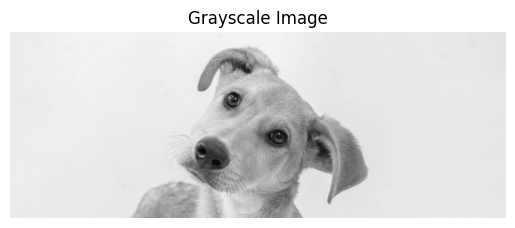

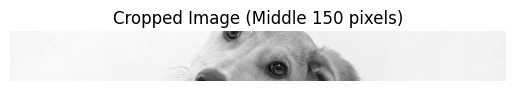

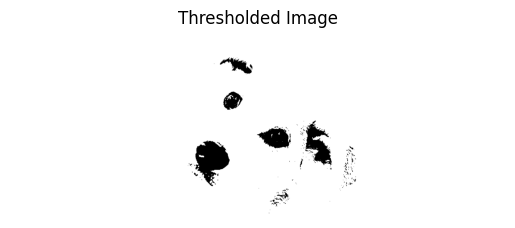

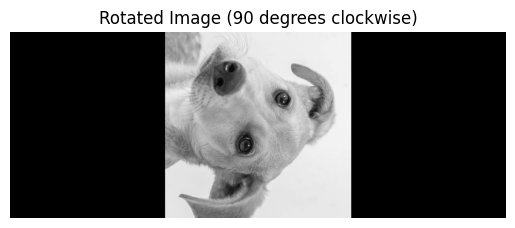

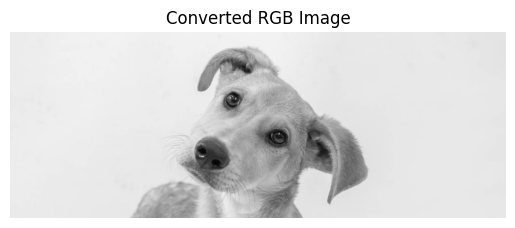

In [5]:
image_path = '/content/dog.jpg'
image = Image.open(image_path).convert('L')  # Load the image and convert to grayscale
plt.imshow(image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

# Extract the middle section of the image (150 pixels)
image_array = np.array(image)
height, width = image_array.shape
start_row = (height - 150) // 2
end_row = start_row + 150
cropped_image = image_array[start_row:end_row, :]
plt.imshow(cropped_image, cmap='gray')
plt.title('Cropped Image (Middle 150 pixels)')
plt.axis('off')
plt.show()

# Apply a simple threshold to the image
thresholded_image = np.where(image_array < 100, 0, 255)
plt.imshow(thresholded_image, cmap='gray')
plt.title('Thresholded Image')
plt.axis('off')
plt.show()

# Rotate the image 90 degrees clockwise
rotated_image = image.rotate(-90)  # Rotate 90 degrees clockwise
plt.imshow(rotated_image, cmap='gray')
plt.title('Rotated Image (90 degrees clockwise)')
plt.axis('off')
plt.show()

# Convert the grayscale image to an RGB image
rgb_image = Image.merge("RGB", (image, image, image))
plt.imshow(rgb_image)
plt.title('Converted RGB Image')
plt.axis('off')
plt.show()


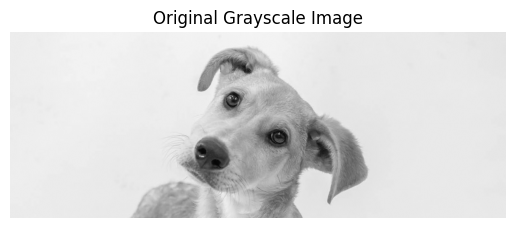

Image shape: (563, 1500)
Covariance matrix shape: (563, 563)


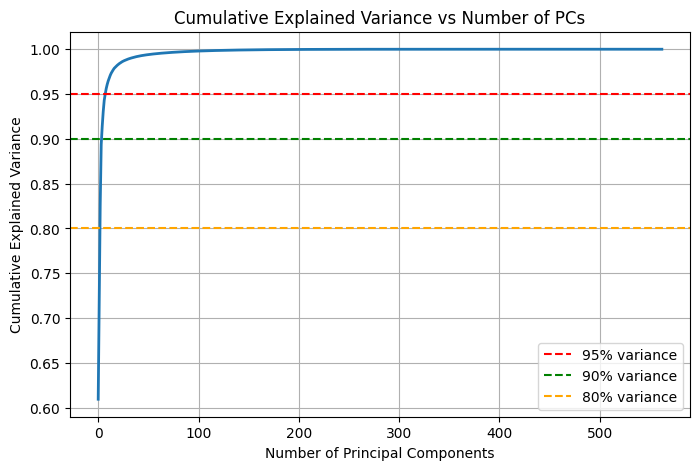

Explained Variance >= 80%: k = 3 components
Explained Variance >= 90%: k = 5 components
Explained Variance >= 95%: k = 9 components
Explained Variance >= 99%: k = 34 components


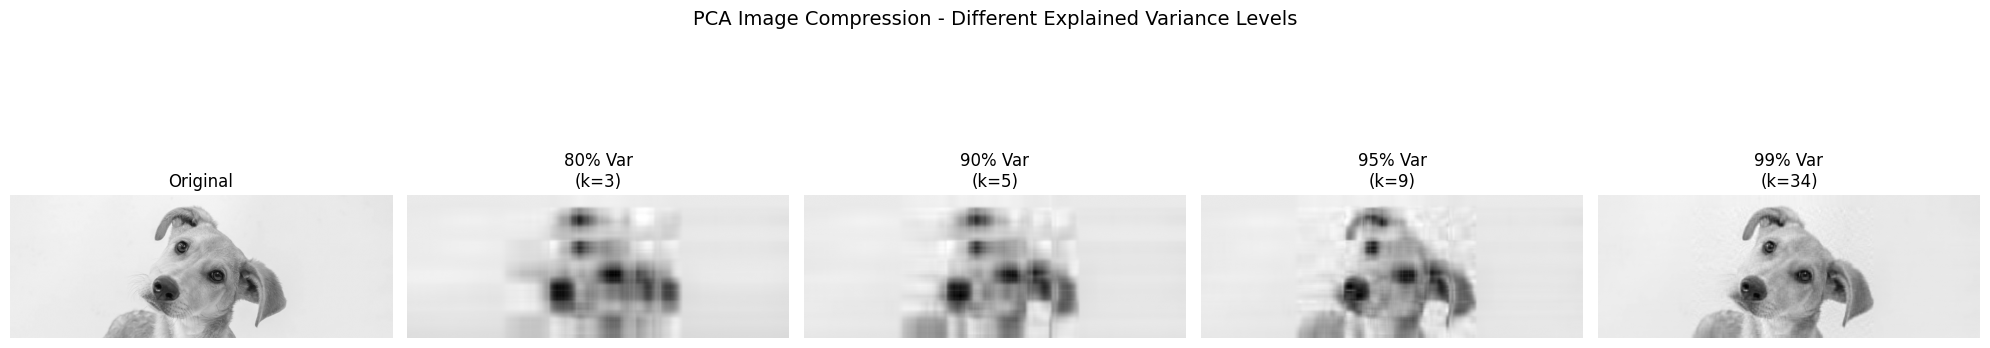


--- Reconstruction Error (MSE) ---
Variance 80% (k=3): MSE = 249.45
Variance 90% (k=5): MSE = 123.67
Variance 95% (k=9): MSE = 63.03
Variance 99% (k=34): MSE = 14.10


In [6]:
# =============================================
# PCA from Scratch for Image Compression
# =============================================

# 1. Load and Prepare Data
image_path = '/content/dog.jpg'
image = Image.open(image_path).convert('L')
image_array = np.array(image, dtype=np.float64)

plt.imshow(image_array, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()
print(f"Image shape: {image_array.shape}")

# Center/Standardize the data (subtract mean of each row)
mean = np.mean(image_array, axis=1, keepdims=True)
standardized_data = image_array - mean

# Calculate the covariance matrix
cov_matrix = np.cov(standardized_data)
print(f"Covariance matrix shape: {cov_matrix.shape}")

# =============================================
# 2. Eigen Decomposition and Identifying Principal Components
# =============================================

# Compute Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Compute explained variance ratio and cumulative sum
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, linewidth=2)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of PCs')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.axhline(y=0.80, color='orange', linestyle='--', label='80% variance')
plt.legend()
plt.grid(True)
plt.show()

# =============================================
# 3. Reconstruction and Experiment
# =============================================

# Find number of components for different explained variance thresholds
variance_thresholds = [0.80, 0.90, 0.95, 0.99]
k_values = []
for threshold in variance_thresholds:
    k = np.argmax(cumulative_variance >= threshold) + 1
    k_values.append(k)
    print(f"Explained Variance >= {threshold*100:.0f}%: k = {k} components")

# Reconstruct images with different numbers of principal components
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# Original image
axes[0].imshow(image_array, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

for i, (k, threshold) in enumerate(zip(k_values, variance_thresholds)):
    # Select top k eigenvectors
    top_eigenvectors = eigenvectors[:, :k]

    # Project data onto principal components (lower-dimensional representation)
    projected = np.dot(top_eigenvectors.T, standardized_data)

    # Reconstruct the image
    reconstructed = np.dot(top_eigenvectors, projected) + mean

    # Clip values to valid pixel range
    reconstructed = np.clip(reconstructed, 0, 255)

    axes[i + 1].imshow(reconstructed, cmap='gray')
    axes[i + 1].set_title(f'{threshold*100:.0f}% Var\n(k={k})')
    axes[i + 1].axis('off')

plt.suptitle('PCA Image Compression - Different Explained Variance Levels', fontsize=14)
plt.tight_layout()
plt.show()

# =============================================
# Evaluation: Reconstruction Error (MSE)
# =============================================
print("\n--- Reconstruction Error (MSE) ---")
for k, threshold in zip(k_values, variance_thresholds):
    top_eigenvectors = eigenvectors[:, :k]
    projected = np.dot(top_eigenvectors.T, standardized_data)
    reconstructed = np.dot(top_eigenvectors, projected) + mean
    reconstructed = np.clip(reconstructed, 0, 255)
    mse = np.mean((image_array - reconstructed) ** 2)
    print(f"Variance {threshold*100:.0f}% (k={k}): MSE = {mse:.2f}")